In [1]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import os
from os.path import join
import json
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
mpl.style.use('../style.mcstyle')   # noqa
import numpy as np
import torch
import seaborn as sns
import pandas as pd
import warnings
from tqdm import tqdm

# Suppress warnings
warnings.filterwarnings('ignore')

Duplicate key in file '../style.mcstyle', line 16 ('font.family: serif')


In [2]:
# weak scaling
ncpu_weak = [64, 512, 1792]
times_weak = [2+58/60, 4+41/60, 11+51/60]  # in minutes

In [19]:
# strong scaling
ncpu_strong = [128, 256, 512, 1024]
times_strong = [13, 7+31/60, 4+55/60, 3+15/60]  # in minutes

In [30]:
1024/128

8.0

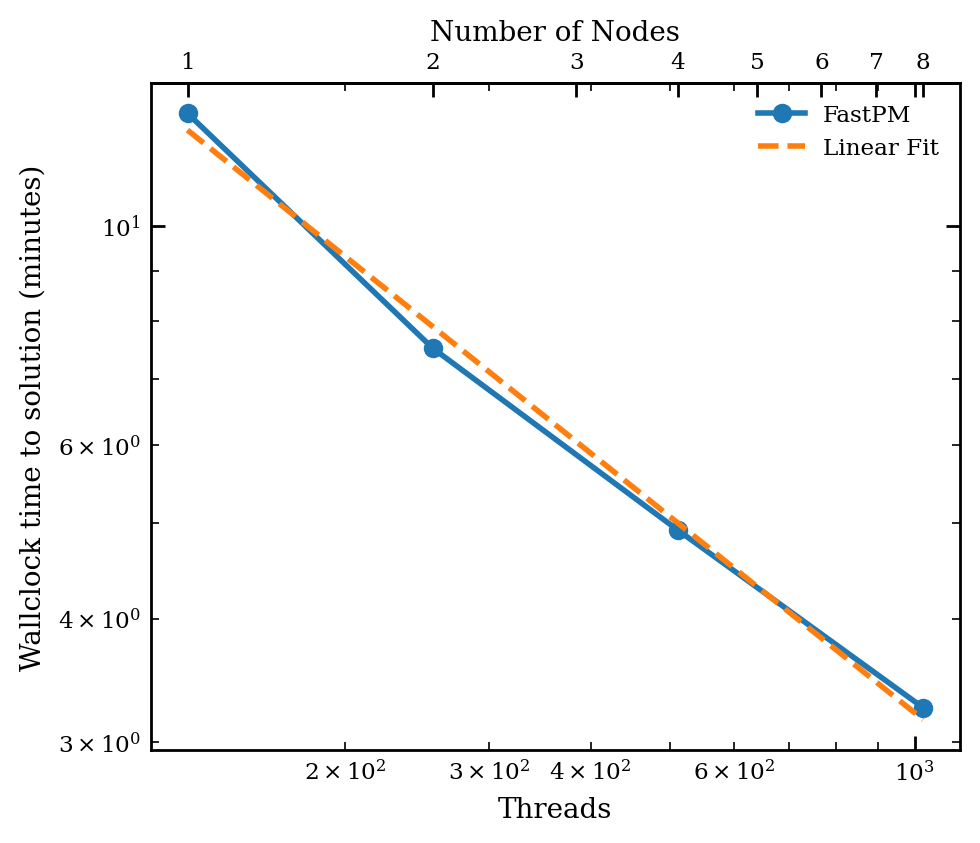

In [34]:
# Fit a linear line to the strong scaling data
log_ncpu_strong = np.log(ncpu_strong)
log_times_strong = np.log(times_strong)

# Perform linear regression
coefficients = np.polyfit(log_ncpu_strong, log_times_strong, 1)  # Linear fit
slope, intercept = coefficients

# Generate fitted line
fitted_line = np.exp(intercept) * np.power(ncpu_strong, slope)

# Plot the original data and the fitted line
fig, ax = plt.subplots(figsize=(5, 4))
ax.loglog(ncpu_strong, times_strong, marker='o', label='FastPM')
ax.loglog(ncpu_strong, fitted_line, linestyle='--', label=f'Linear Fit')
# ax.set_title('Strong Scaling with Linear Fit')
ax.set_xlabel('Threads')
ax.set_ylabel('Wallclock time to solution (minutes)')
ax.legend()
plt.tight_layout()


def cpu_to_nodes(x):
    return np.array(x) / 128


def nodes_to_cpu(x):
    return np.array(x) * 128

secax_strong = ax.secondary_xaxis(
    'top', functions=(cpu_to_nodes, nodes_to_cpu))
secax_strong.set_xlabel('Number of Nodes')
secax_strong.set_xticks(range(1, 10))
secax_strong.set_xticklabels([str(i) for i in range(1, 10)])

plt.savefig('strong_scaling.pdf', bbox_inches='tight')

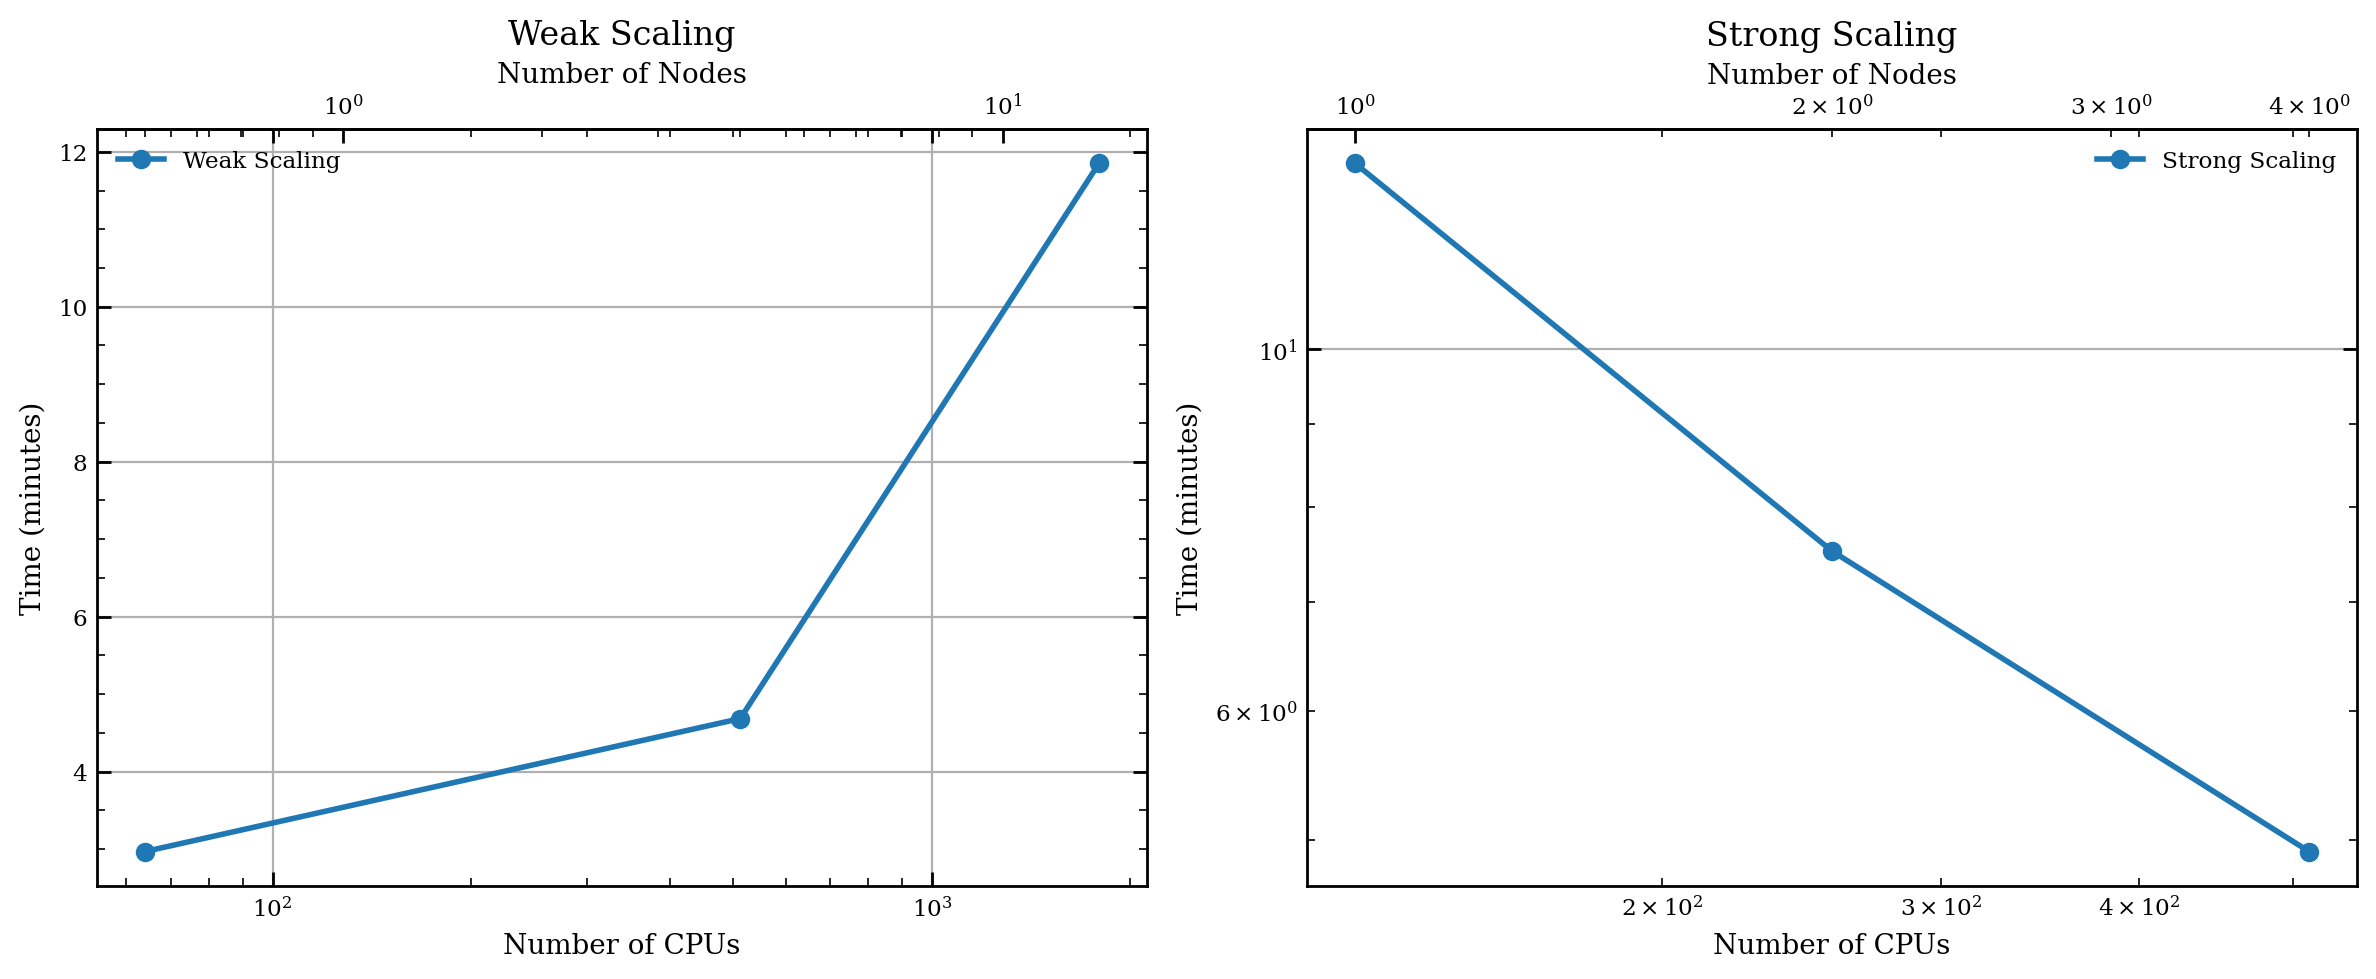

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Weak scaling plot
axes[0].semilogx()
axes[0].plot(ncpu_weak, times_weak, marker='o', label='Weak Scaling')
axes[0].set_title('Weak Scaling')
axes[0].set_xlabel('Number of CPUs')
axes[0].set_ylabel('Time (minutes)')
axes[0].legend()
axes[0].grid(True)

# Strong scaling plot
axes[1].loglog()
axes[1].plot(ncpu_strong, times_strong, marker='o', label='Strong Scaling')
axes[1].set_title('Strong Scaling')
axes[1].set_xlabel('Number of CPUs')
axes[1].set_ylabel('Time (minutes)')
axes[1].legend()
axes[1].grid(True)

# Adding secondary x-axis for 'number of nodes'


def cpu_to_nodes(x):
    return np.array(x) / 128


def nodes_to_cpu(x):
    return np.array(x) * 128


# Weak scaling secondary x-axis
secax_weak = axes[0].secondary_xaxis(
    'top', functions=(cpu_to_nodes, nodes_to_cpu))
secax_weak.set_xlabel('Number of Nodes')

# Strong scaling secondary x-axis
secax_strong = axes[1].secondary_xaxis(
    'top', functions=(cpu_to_nodes, nodes_to_cpu))
secax_strong.set_xlabel('Number of Nodes')

plt.tight_layout()
plt.show()

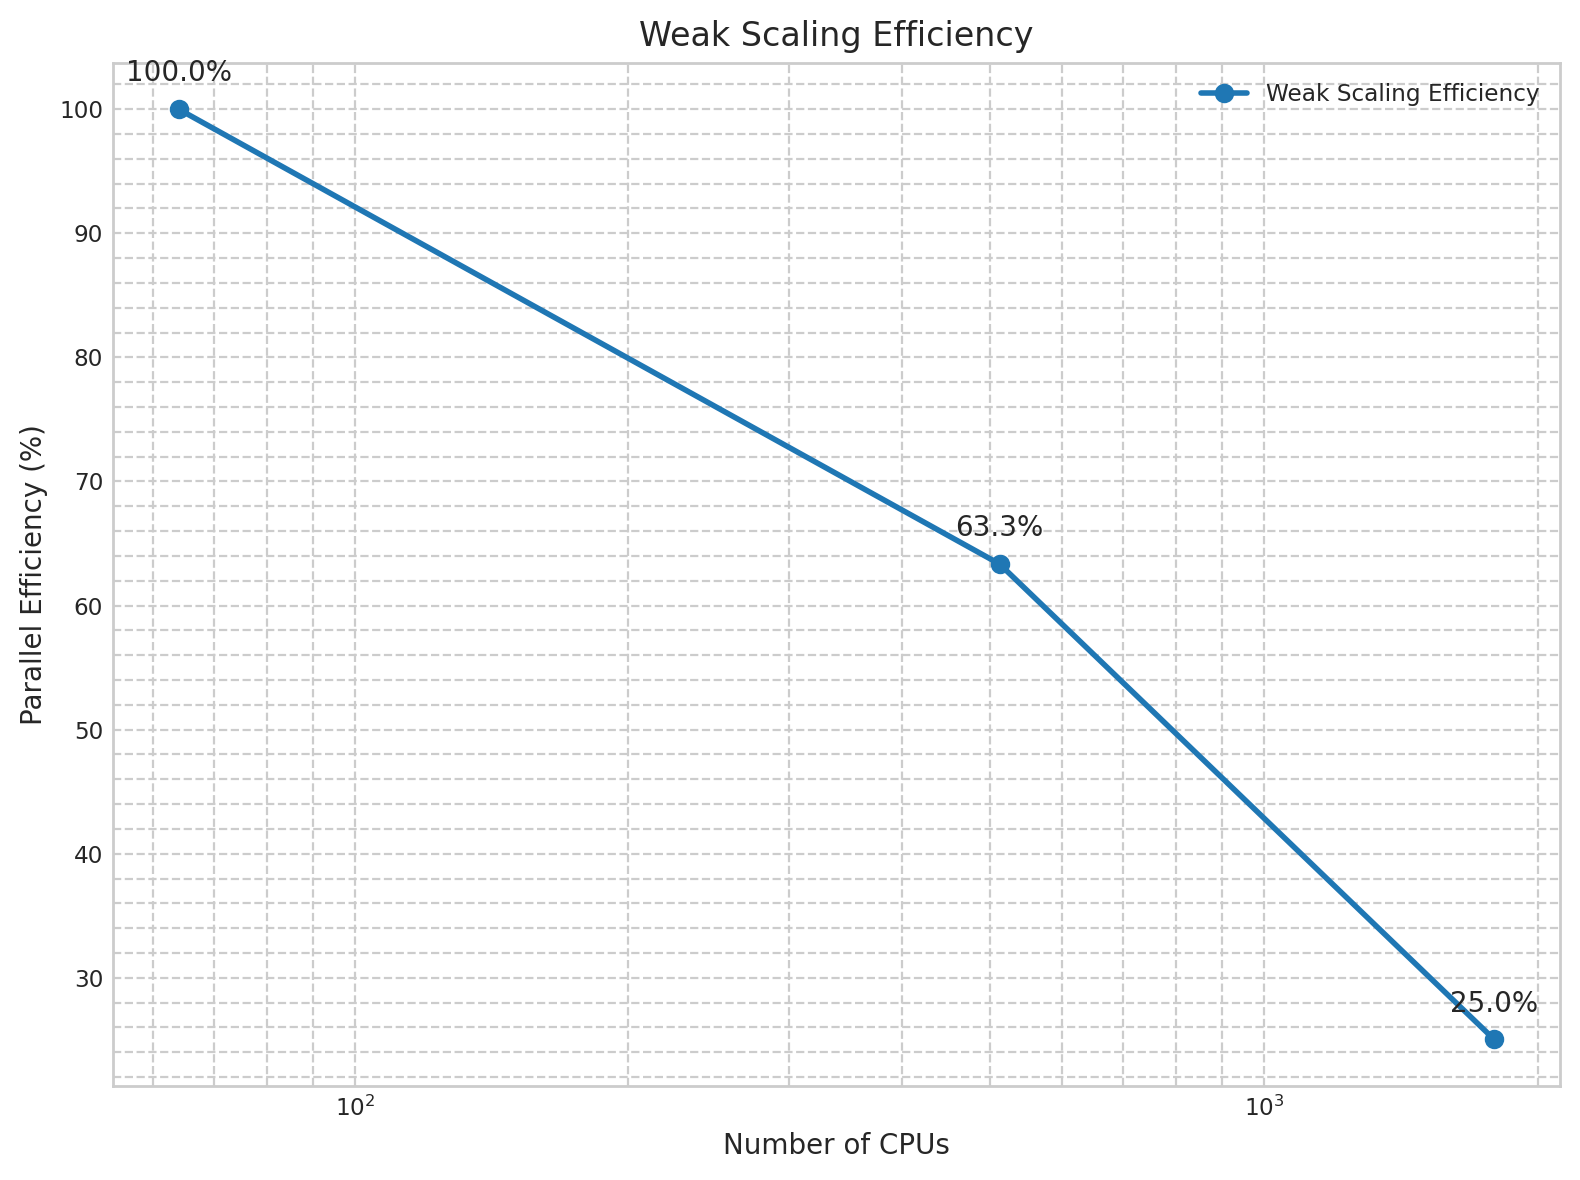

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Your Data ---
ncpu_weak = np.array([64, 512, 1792])
# Convert times to minutes
times_weak_minutes = np.array([2 + 58/60, 4 + 41/60, 11 + 51/60])

# --- Calculation ---
# The baseline time is the time for the first run (64 CPUs)
baseline_time = times_weak_minutes[0]
# Calculate parallel efficiency
efficiency = (baseline_time / times_weak_minutes) * 100

# --- Plotting ---
plt.style.use('seaborn-v0_8-whitegrid')  # Sets a nice plot style
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(ncpu_weak, efficiency, marker='o',
        linestyle='-', label='Weak Scaling Efficiency')

# Annotate the points with their percentage value
for i, txt in enumerate(efficiency):
    ax.annotate(f'{txt:.1f}%', (ncpu_weak[i], efficiency[i]),
                textcoords="offset points", xytext=(0, 10), ha='center')

# Formatting the plot
ax.set_xscale('log')
ax.set_xlabel('Number of CPUs')
ax.set_ylabel('Parallel Efficiency (%)')
ax.set_title('Weak Scaling Efficiency')
ax.grid(True, which="both", ls="--")
ax.legend()
plt.tight_layout()
plt.show()